<div style="border-bottom: 4px solid #003366; margin-bottom: 20px; padding-bottom: 10px; display: flex; justify-content: space-between; align-items: center;">
    <div style="flex-grow: 1;">
        <h1 style="color: #003366; font-family: 'Helvetica', sans-serif; margin-bottom: 5px;">MAT1610: Cálculo I</h1>
        <h2 style="color: #555; margin-top: 0; margin-bottom: 10px;">Laboratorio 07: Análisis Cualitativo de Funciones</h2>
        <p style="margin: 2px 0;"><b>Profesores:</b> Manuel A. Sánchez | <b>Fecha:</b> 4 de Junio, 2026</p>
        <p style="margin: 2px 0;"><b>Institución:</b> Facultad de Matemáticas, Pontificia Universidad Católica de Chile</p>
    </div>
    <div style="flex: 0 0 auto; margin-left: 20px;">
        <img src="../source/FacMatematicas-15.png" 
             alt="Logo UC" 
             style="height: 60px; width: auto;">
    </div>
</div>

<div style="border: 1px solid #2980b9; border-left: 8px solid #2980b9; padding: 15px; border-radius: 5px; margin-bottom: 20px;">
    <h3 style="color: #2980b9; margin-top: 0;">Contexto y Referencias</h3>
    <p>Bienvenidos al séptimo laboratorio del curso. Hoy nos adentraremos en el <b>Análisis Cualitativo de Funciones</b>, un conjunto de técnicas derivadas del Cálculo Diferencial que nos permiten esbozar y entender el comportamiento global de cualquier función. Utilizaremos las herramientas de derivación y límites para encontrar "la anatomía" de las curvas: dónde suben, dónde bajan, su concavidad y su comportamiento a largo plazo. Este laboratorio está referenciado en las aplicaciones de la derivada del texto de Stewart.</p>
</div>

<div style="display: flex; gap: 20px;">
    <div style="flex: 1; border: 1px solid #27ae60; border-left: 8px solid #27ae60; padding: 15px; border-radius: 5px;">
        <h3 style="color: #27ae60; margin-top: 0;">Contenidos</h3>
        <ol>
            <li>Intervalos de crecimiento y puntos críticos.</li>
            <li>Intervalos de concavidad y puntos de inflexión.</li>
            <li>Asíntotas horizontales, verticales y oblicuas.</li>
        </ol>
    </div>
    <div style="flex: 1; border: 1px solid #f39c12; border-left: 8px solid #f39c12; padding: 15px; border-radius: 5px;">
        <h3 style="color: #f39c12; margin-top: 0;">Objetivos de Aprendizaje</h3>
        <ul>
            <li>Identificar el crecimiento/decrecimiento usando la primera derivada mediante computación simbólica.</li>
            <li>Clasificar puntos críticos y puntos de inflexión aplicando <code>SymPy</code>.</li>
            <li>Calcular algebraicamente e ilustrar computacionalmente distintos tipos de asíntotas.</li>
        </ul>
    </div>
</div>

In [1]:
# importar librerias de la sesion
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from ipywidgets import interact, widgets

# Configuración para visualización matemática
sp.init_printing()
%matplotlib inline

# Configuración de estilo
try: 
    plt.style.use('seaborn-v0_8-whitegrid')
except: 
    plt.style.use('seaborn-whitegrid')
plt.rcParams['figure.figsize'] = (7, 4.5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# **1. Intervalos de Crecimiento y Puntos Críticos**

💡 **Intuición Geométrica:** Geométricamente, la derivada $f'(x)$ mide la pendiente de la recta tangente a la curva de $f(x)$. 
- Si $f'(x) > 0$ en un intervalo, la recta tangente apunta hacia arriba, indicando que la función **crece**.
- Si $f'(x) < 0$ en un intervalo, la tangente apunta hacia abajo, indicando que la función **decrece**.
- Los lugares donde la curva se "aplana" ($f'(x) = 0$) o tiene "picos" ($f'(x)$ no existe) se denominan **puntos críticos**. Son los principales candidatos a ser máximos o mínimos locales de sistemas físicos.

💻 **Traducción Computacional:**
Para aplicar esto en Python, utilizaremos `sp.diff()` para obtener analíticamente la derivada y `sp.solve()` para encontrar las raíces de $f'(x) = 0$.

### Ejemplo 1.1: Polinomio Cúbico Clásico
Analicemos la función $f(x) = \frac{1}{3}x^3 - x^2 - 3x + 4$. Encontraremos sus puntos críticos y visualizaremos sus intervalos de monotonía.

Primera Derivada f'(x) = 1.0*x**2 - 2*x - 3
Puntos Críticos en x = [-1.00000000000000, 3.00000000000000]


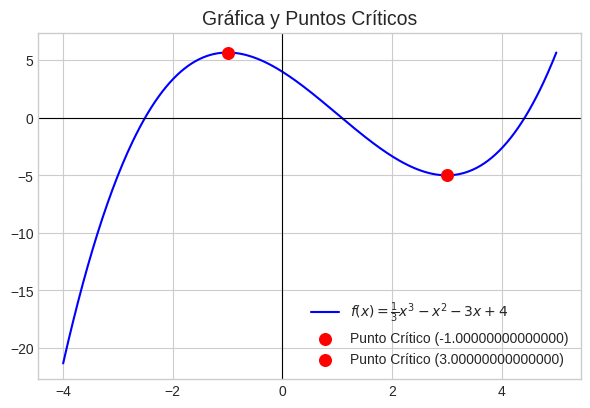

In [2]:
x = sp.symbols('x')
f1_expr = (1/3)*x**3 - x**2 - 3*x + 4

# 1. Encontrar la primera derivada
f1_prime = sp.diff(f1_expr, x)
print("Primera Derivada f'(x) =", f1_prime)

# 2. Encontrar puntos críticos resolviendo f'(x) = 0
pc1 = sp.solve(f1_prime, x)
print("Puntos Críticos en x =", pc1)

# 3. Visualización con numpy y matplotlib
f1_num = sp.lambdify(x, f1_expr, "numpy")
x_vals = np.linspace(-4, 5, 400)
y_vals = f1_num(x_vals)

plt.plot(x_vals, y_vals, label=r'$f(x) = \frac{1}{3}x^3 - x^2 - 3x + 4$', color='blue')

# Marcar puntos críticos
for p in pc1:
    plt.scatter(p, f1_num(float(p)), color='red', s=70, zorder=5, label=f'Punto Crítico ({p})')

plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.title("Gráfica y Puntos Críticos")
plt.legend()
plt.show()

### Ejemplo 1.2: Aplicación en Termodinámica (Perfil de Temperatura)
Suponga que la temperatura interna de un componente de motor obedece al modelo térmico $T(t) = t^2 e^{-t/2}$ (para $t \geq 0$). Usaremos las derivadas para encontrar en qué minuto exacto ocurre el pico de calor (máximo térmico).

El pico de temperatura ocurre en t = 4 minutos


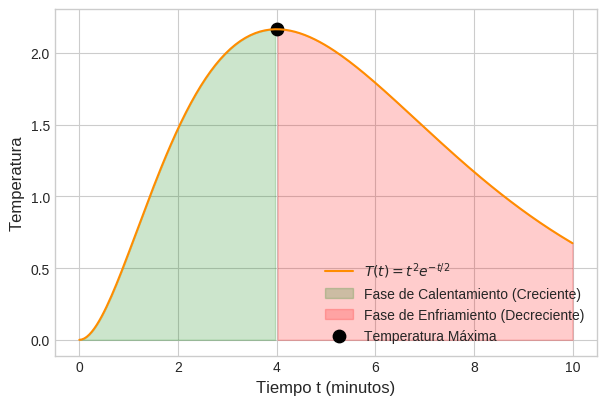

In [3]:
t = sp.symbols('t', positive=True) # El tiempo t >= 0
T_expr = t**2 * sp.exp(-t/2)

# Derivada del perfil de temperatura
T_prime = sp.diff(T_expr, t)
pc_T = sp.solve(T_prime, t)
print("El pico de temperatura ocurre en t =", pc_T[0], "minutos")

# Graficando el gradiente térmico
T_num = sp.lambdify(t, T_expr, "numpy")
t_vals = np.linspace(0, 10, 200)

plt.plot(t_vals, T_num(t_vals), color='darkorange', label=r'$T(t) = t^2 e^{-t/2}$')
plt.fill_between(t_vals, T_num(t_vals), where=(t_vals < float(pc_T[0])), color='green', alpha=0.2, label='Fase de Calentamiento (Creciente)')
plt.fill_between(t_vals, T_num(t_vals), where=(t_vals > float(pc_T[0])), color='red', alpha=0.2, label='Fase de Enfriamiento (Decreciente)')

plt.scatter(float(pc_T[0]), T_num(float(pc_T[0])), color='black', s=80, label='Temperatura Máxima')
plt.xlabel('Tiempo t (minutos)')
plt.ylabel('Temperatura')
plt.legend()
plt.show()

### Ejemplo 1.3: Crecimiento Estricto (Carga de un Capacitor)
No todas las funciones tienen puntos críticos que resulten en picos o valles. La carga de un capacitor en un circuito RC está dada por $Q(t) = Q_0(1 - e^{-t/(RC)})$. Demostraremos computacionalmente que para $t > 0$, la función siempre es creciente.

Expresión de Q'(t) = Q0*exp(-t/(C*R))/(C*R)
Dado que Q0, R, C son constantes positivas de componentes físicos, e^(-t/RC) siempre es positivo.
Por ende, Q'(t) > 0 para todo t. La carga siempre crece.


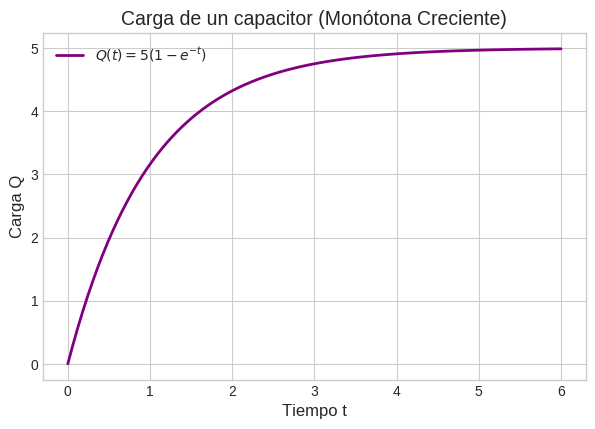

In [4]:
t, R, C, Q0 = sp.symbols('t R C Q0', positive=True, real=True)
Q_expr = Q0 * (1 - sp.exp(-t / (R*C)))

# Calculamos la derivada respecto al tiempo
Q_prime = sp.diff(Q_expr, t)

print("Expresión de Q'(t) =", Q_prime)
print("Dado que Q0, R, C son constantes positivas de componentes físicos, e^(-t/RC) siempre es positivo.")
print("Por ende, Q'(t) > 0 para todo t. La carga siempre crece.")

# Graficando un caso específico R=1, C=1, Q0=5
Q_specific = Q_expr.subs({R: 1, C: 1, Q0: 5})
Q_num = sp.lambdify(t, Q_specific, "numpy")
t_vals = np.linspace(0, 6, 100)

plt.plot(t_vals, Q_num(t_vals), color='purple', lw=2, label=r'$Q(t) = 5(1 - e^{-t})$')
plt.title('Carga de un capacitor (Monótona Creciente)')
plt.xlabel('Tiempo t')
plt.ylabel('Carga Q')
plt.legend()
plt.show()

# **2. Intervalos de Concavidad y Puntos de Inflexión**

💡 **Intuición Geométrica:** La segunda derivada $f''(x)$ nos habla de la "aceleración" de la curva, o cómo cambia la pendiente. 
- Si $f''(x) > 0$, la curva se flexiona hacia arriba (tiene forma de $U$, retiene agua). Se dice que es **cóncava hacia arriba**.
- Si $f''(x) < 0$, la curva se flexiona hacia abajo (forma de puente). Es **cóncava hacia abajo**.
- Los puntos donde la concavidad cambia se denominan **puntos de inflexión**. En ingeniería civil (vigas) o física, estos puntos representan lugares de transición de esfuerzo nulo.

💻 **Traducción Computacional:**
Calcularemos $f''(x)$ usando `sp.diff(f, x, 2)` y buscaremos inflexiones resolviendo `sp.solve(f_double_prime, x)`.

### Ejemplo 2.1: Análisis de un Polinomio de Grado 4
Sea $f(x) = x^4 - 6x^2 + 5$. Buscaremos sus puntos de inflexión y destacaremos los intervalos de distinta concavidad en la gráfica.

Segunda Derivada f''(x) = 12*(x**2 - 1)
Puntos de Inflexión en x = [-1, 1]


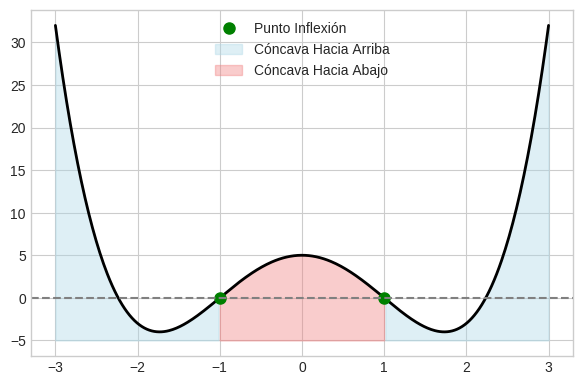

In [5]:
f2_expr = x**4 - 6*x**2 + 5

# Segunda derivada
f2_double_prime = sp.diff(f2_expr, x, 2)
print("Segunda Derivada f''(x) =", f2_double_prime)

# Puntos de inflexión
puntos_inflexion = sp.solve(f2_double_prime, x)
print("Puntos de Inflexión en x =", puntos_inflexion)

# Visualización con sombreado de concavidad
f2_num = sp.lambdify(x, f2_expr, "numpy")
x_vals = np.linspace(-3, 3, 400)

plt.plot(x_vals, f2_num(x_vals), color='black', lw=2)

# Colorear basado en los puntos de inflexion (-1 y 1)
plt.fill_between(x_vals, f2_num(x_vals), -5, where=(x_vals < -1), color='lightblue', alpha=0.4, label='Cóncava Hacia Arriba')
plt.fill_between(x_vals, f2_num(x_vals), -5, where=((x_vals >= -1) & (x_vals <= 1)), color='lightcoral', alpha=0.4, label='Cóncava Hacia Abajo')
plt.fill_between(x_vals, f2_num(x_vals), -5, where=(x_vals > 1), color='lightblue', alpha=0.4)

for pi in puntos_inflexion:
    plt.plot(float(pi), f2_num(float(pi)), 'go', markersize=8, label='Punto Inflexión' if float(pi) == 1 else "")

plt.axhline(0, color='gray', linestyle='--')
plt.legend()
plt.show()

### Ejemplo 2.2: La Campana de Gauss (Estadística y Error de Medición)
La función $f(x) = e^{-x^2/2}$ es central en la teoría de probabilidad. Sus puntos de inflexión están directamente relacionados con la desviación estándar matemática del fenómeno estudiado.

La Campana de Gauss cambia su concavidad exactamente en x = [-1, 1]


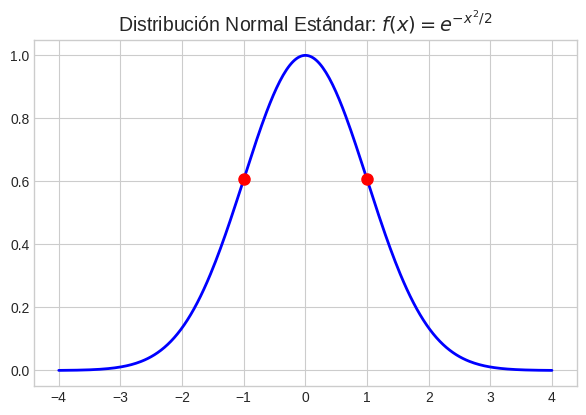

In [6]:
f_gauss = sp.exp(-x**2 / 2)

# Segunda derivada
f_gauss_2p = sp.diff(f_gauss, x, 2)
inflex_gauss = sp.solve(f_gauss_2p, x)

print("La Campana de Gauss cambia su concavidad exactamente en x =", inflex_gauss)

# Gráfica
fg_num = sp.lambdify(x, f_gauss, "numpy")
x_vals = np.linspace(-4, 4, 300)

plt.plot(x_vals, fg_num(x_vals), 'b-', lw=2)
for p in inflex_gauss:
    plt.plot(float(p), fg_num(float(p)), 'ro', markersize=8)

plt.title(r'Distribución Normal Estándar: $f(x) = e^{-x^2 / 2}$')
plt.show()

### Ejemplo 2.3: Deflexión de una Viga (Ingeniería Estructural)
La deformación de una viga apoyada uniformemente cargada se aproxima por $y(x) = k(x^4 - 2Lx^3 + L^3x)$. Verificaremos analíticamente si existen puntos de inflexión (donde el momento flector sería nulo) en el rango $0 \leq x \leq L$.

In [7]:
L, k = sp.symbols('L k', positive=True, real=True)
# Definimos la deflexión de la viga
y_viga = k * (x**4 - 2*L*x**3 + L**3 * x)

# El momento flector es proporcional a la segunda derivada
momento_flector = sp.diff(y_viga, x, 2)
print("Segunda derivada (proporcional al Momento Flector) =", momento_flector)

inflex_viga = sp.solve(momento_flector, x)
print("Puntos de momento nulo en x =", inflex_viga)
print("Nota: El punto x = L está en el borde, no en el interior de la viga.")

Segunda derivada (proporcional al Momento Flector) = -12*k*x*(L - x)
Puntos de momento nulo en x = [0, L]
Nota: El punto x = L está en el borde, no en el interior de la viga.


# **3. Asíntotas Horizontales, Verticales y Oblicuas**

💡 **Intuición Geométrica:** Las asíntotas revelan qué le sucede a un sistema en sus "límites extremos".
- **Asíntota Vertical (AV):** Ocurre si la función explota hacia $\pm \infty$ al acercarse a un valor $x = a$ (ej. una resonancia física). Evaluamos $\lim_{x \to a} f(x)$.
- **Asíntota Horizontal (AH):** Describe la estabilización o el equilibrio del sistema cuando $x \to \pm \infty$. Evaluamos $\lim_{x \to \infty} f(x)$.
- **Asíntota Oblicua (AO):** Si para valores muy grandes la curva se comporta matemáticamente como una línea diagonal $y = mx + n$. Ocurre típicamente en cocientes de polinomios donde el grado del numerador supera en 1 al del denominador.

💻 **Traducción Computacional:**
Para encontrar estas fronteras, la herramienta estelar es la función `sp.limit(f, x, valor)`.

### Ejemplo 3.1: Filtro Racional (Asíntotas Verticales y Horizontales)
Dada la función de respuesta $H(s) = \frac{2s+1}{s-3}$, extraigamos sus características asintóticas.

Asíntota Horizontal en y = 2
Límite por la derecha de s=3 es: oo
Límite por la izquierda de s=3 es: -oo
Por tanto, existe una Asíntota Vertical en s = 3


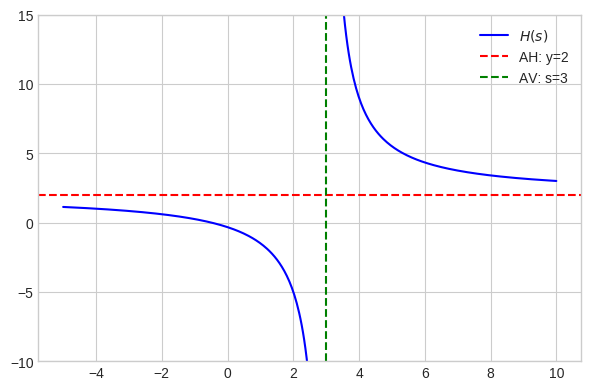

In [8]:
s = sp.symbols('s')
H_expr = (2*s + 1) / (s - 3)

# 1. Asíntota Horizontal: límite cuando s tiende a infinito
AH = sp.limit(H_expr, s, sp.oo)
print("Asíntota Horizontal en y =", AH)

# 2. Asíntota Vertical: observando el denominador, exploramos el límite en s=3
AV_der = sp.limit(H_expr, s, 3, dir='+')
AV_izq = sp.limit(H_expr, s, 3, dir='-')
print("Límite por la derecha de s=3 es:", AV_der)
print("Límite por la izquierda de s=3 es:", AV_izq)
print("Por tanto, existe una Asíntota Vertical en s = 3")

# Gráfica
H_num = sp.lambdify(s, H_expr, "numpy")
s_vals = np.linspace(-5, 10, 400)
# Evitar el punto de la asíntota vertical en la gráfica dividiendo el array
s_vals_izq = s_vals[s_vals < 2.9]
s_vals_der = s_vals[s_vals > 3.1]

plt.plot(s_vals_izq, H_num(s_vals_izq), 'b')
plt.plot(s_vals_der, H_num(s_vals_der), 'b', label=r'$H(s)$')

plt.axhline(float(AH), color='red', linestyle='--', label=f'AH: y={AH}')
plt.axvline(3, color='green', linestyle='--', label='AV: s=3')

plt.ylim(-10, 15)
plt.legend()
plt.show()

### Ejemplo 3.2: Asíntotas Oblicuas
Busquemos la asíntota oblicua de la función $f(x) = \frac{x^2 + 1}{x}$. Las ecuaciones matemáticas dictan que $m = \lim_{x \to \infty} \frac{f(x)}{x}$ y $n = \lim_{x \to \infty} (f(x) - mx)$.

La asíntota oblicua es la recta y = 1x + 0


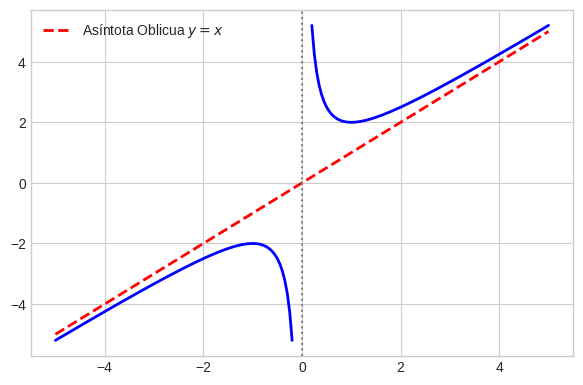

In [9]:
f3_expr = (x**2 + 1) / x

# Pendiente m
m = sp.limit(f3_expr / x, x, sp.oo)

# Intersección n
n = sp.limit(f3_expr - m*x, x, sp.oo)

print(f"La asíntota oblicua es la recta y = {m}x + {n}")

# Graficando
f3_num = sp.lambdify(x, f3_expr, 'numpy')
AO_num = sp.lambdify(x, m*x + n, 'numpy')

x_vals1 = np.linspace(-5, -0.2, 100)
x_vals2 = np.linspace(0.2, 5, 100)

plt.plot(x_vals1, f3_num(x_vals1), 'b', lw=2)
plt.plot(x_vals2, f3_num(x_vals2), 'b', lw=2)

x_full = np.linspace(-5, 5, 100)
plt.plot(x_full, AO_num(x_full), 'r--', lw=2, label=r'Asíntota Oblicua $y=x$')
plt.axvline(0, color='gray', linestyle=':')
plt.legend()
plt.show()

### Ejemplo 3.3: Modelo Logístico de Población (Saturación)
Los ecosistemas o redes (como la carga de servidores) siguen un modelo logístico: $P(t) = \frac{1000}{1 + 9e^{-t}}$. Analicemos su asíntota horizontal superior, que representa la "capacidad de carga" matemática del sistema.

La capacidad máxima de carga del sistema es poblacion = 1000


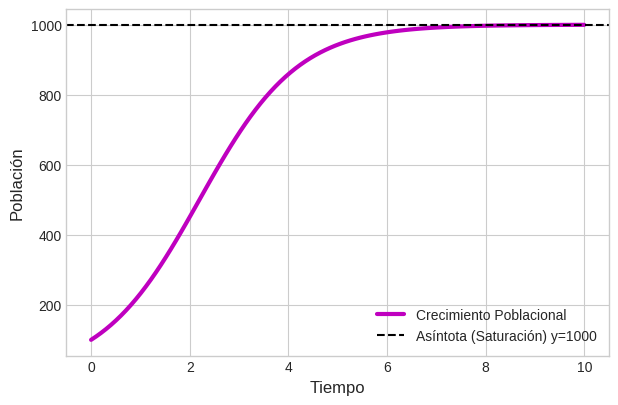

In [10]:
P_expr = 1000 / (1 + 9*sp.exp(-t))

# En el tiempo infinito:
capacidad_carga = sp.limit(P_expr, t, sp.oo)
print("La capacidad máxima de carga del sistema es poblacion =", capacidad_carga)

# Graficando
P_num = sp.lambdify(t, P_expr, 'numpy')
t_vals = np.linspace(0, 10, 100)

plt.plot(t_vals, P_num(t_vals), 'm-', lw=3, label="Crecimiento Poblacional")
plt.axhline(float(capacidad_carga), color='k', linestyle='--', label=f'Asíntota (Saturación) y={capacidad_carga}')

plt.xlabel("Tiempo")
plt.ylabel("Población")
plt.legend(loc='lower right')
plt.show()

<div class="alert alert-block alert-success" style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 15px; border-radius: 5px;"> 
    <h2 style="color: #2e7d32; margin-top: 0;">🏁 Ticket de Salida</h2>
    <p style="font-size: 1.1em; color: #1b5e20;"><strong>¡Felicidades!</strong> Hemos llegado al final de los contenidos de este laboratorio. Ahora es tu turno de poner en práctica lo que aprendiste resolviendo los siguientes retos computacionales. Utiliza bloques de código de Python para responder a cada inciso.</p>
    <h3 style="color: #2e7d32; margin-top: 15px;">💻 Ejercicios: </h3>
</div>

### Ejercicio 1: Optimización de Rendimientos Marginales (Costos)
La función de costo total de fabricar $x$ unidades de un dron industrial está modelada por $C(x) = x^3 - 15x^2 + 80x + 100$. 
1. Utilizando derivadas en `SymPy`, encuentra el punto de inflexión de esta curva de costos.
2. Económicamente, este punto representa el momento donde el costo marginal deja de disminuir y empieza a aumentar. Genera una gráfica que resalte este punto y sombrea la diferencia de concavidad.

---

In [11]:
# Escriba su código aquí

### Ejercicio 2: Diseño de Filtro de Frecuencia (Asíntotas)
En el diseño de sistemas de control, un filtro se modela matemáticamente como la transferencia racional: 
$$H(s) = \frac{s^2 - 1}{s^2 - 4}$$
1. Identifica y calcula con la función límite de `SymPy` **todas** las asíntotas horizontales y verticales de esta función.
2. Encuentra matemáticamente los puntos críticos de $H(s)$ (donde $H'(s) = 0$).
3. Grafica la función entre $s = -5$ y $s = 5$ asegurándote de utilizar cortes en los arreglos de `numpy` para no cruzar líneas feas por encima de las asíntotas verticales.

---

In [12]:
# Escriba su código aquí

### Ejercicio 3: Automatización de la Asíntota Oblicua
Crea un bloque de código genérico (una función en Python) que reciba de entrada una expresión simbólica cualquiera `f_x` y su variable simbólica `x`. 
1. El código debe calcular analíticamente e imprimir la ecuación de la asíntota oblicua si esta existe, calculando $m$ y $n$ con límites al infinito.
2. Pon a prueba tu código introduciendo la función compleja de arrastre aerodinámico simplificada: $f(x) = \frac{3x^3 + 2x^2 + x}{x^2 + 1}$.

---

In [13]:
# Escriba su código aquí

<div style="width: 100%; border-top: 2px solid #ddd; padding-top: 15px; margin-top: 30px; font-family: sans-serif; font-size: 0.85em; color: #666;">
    <p>
        <strong>© 2026 Manuel A. Sánchez </strong><br>
        <a href="https://www.mat.uc.cl/" style="color: #003366; text-decoration: none;">Facultad de Matemáticas</a><br>
        Pontificia Universidad Católica de Chile
    </p>
    <p>
        <i>Este material está diseñado para el curso MAT1610 y no debe ser redistribuido sin permiso explícito.</i>
    </p>
</div>